In [1]:
# U-Net Image segmentation Code
# ------------------------------

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


IMG_SIZE = 128

# ---------------------------------------------
# 1. Create syntheric Dataset (Images + Masks)
# ---------------------------------------------

def create_dataset(samples=300):

    images = []
    masks = []

    for _ in range(samples):

        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        mask = np.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=np.uint8)

        x = np.random.randint(30, 100)
        y = np.random.randint(30, 100)
        r = np.random.randint(10, 25)

        cv2.circle(img, (x, y), r, (255, 255, 255), -1)
        cv2.circle(mask, (x, y), r, 255,  -1)

        images.append(img /255.0)
        masks.append(mask /255.0)

    return np.array(images), np.array(masks)

x, y, = create_dataset()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2 , random_state=1)

In [2]:
# -----------------------------------
# 2. Convolution Block
# -----------------------------------

def conv_block(x, filters):

    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)

    return x

In [3]:
# -----------------------------------
# 3. Build U-Net Architecture
# -----------------------------------

inputs = tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3))

# Encoder:

c1 = conv_block(inputs, 32)
p1 = tf.keras.layers.MaxPooling2D()(c1)

c2 = conv_block(p1, 64)
p2 = tf.keras.layers.MaxPooling2D()(c2)

c3 = conv_block(p2, 128)
p3 = tf.keras.layers.MaxPooling2D()(c3)

# Bottleneck:

bn = conv_block(p3, 256)

# Decoder:

u1 = tf.keras.layers.UpSampling2D()(bn)
Concat1 = tf.keras.layers.Concatenate()([u1, c3])
c4 = conv_block(Concat1, 128)

u2 = tf.keras.layers.UpSampling2D()(c4)
Concat2 = tf.keras.layers.Concatenate()([u2, c2])
c5 = conv_block(Concat2, 64)

u3 = tf.keras.layers.UpSampling2D()(c5)
Concat3 = tf.keras.layers.Concatenate()([u3, c1])
c6 = conv_block(Concat3, 32)

outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c6)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# -----------------------------------
# 4. Train Model
# -----------------------------------

history = model.fit(
    x_train, y_train,
    validation_split=0.3,
    epochs=5,
    batch_size=8
)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 128ms/step - accuracy: 0.9343 - loss: 0.2632 - val_accuracy: 0.9961 - val_loss: 0.0083
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.9982 - loss: 0.0046 - val_accuracy: 0.9982 - val_loss: 0.0043
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9987 - val_loss: 0.0031
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 0.9998 - val_loss: 8.8382e-04


In [5]:
# -----------------------------------
# 5. Evaluate Model.
# -----------------------------------

loss, acc = model.evaluate(x_test, y_test)
print('Loss:', loss)
print('Accuracy:', acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9998 - loss: 9.0270e-04
Loss: 0.0009026961051858962
Accuracy: 0.9997873902320862


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


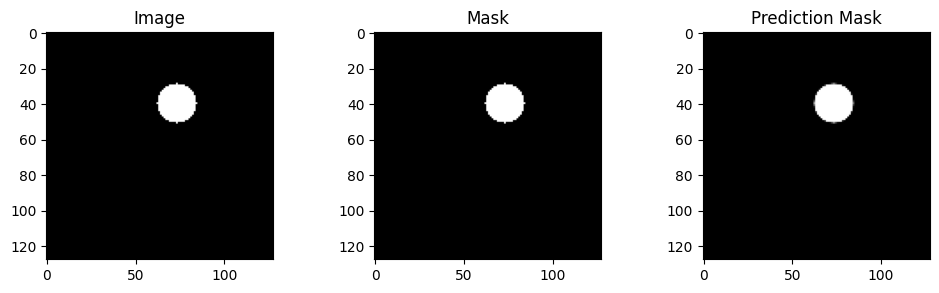

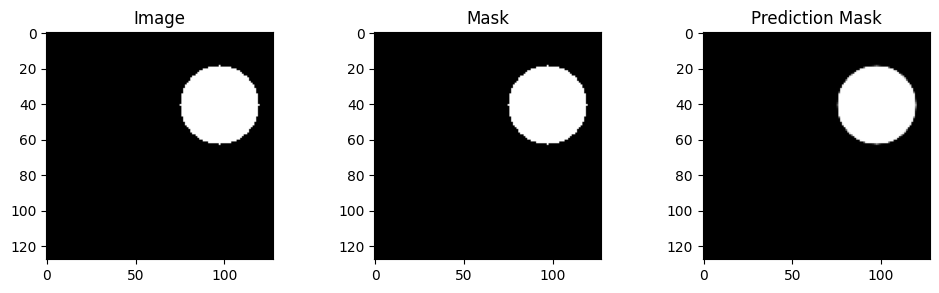

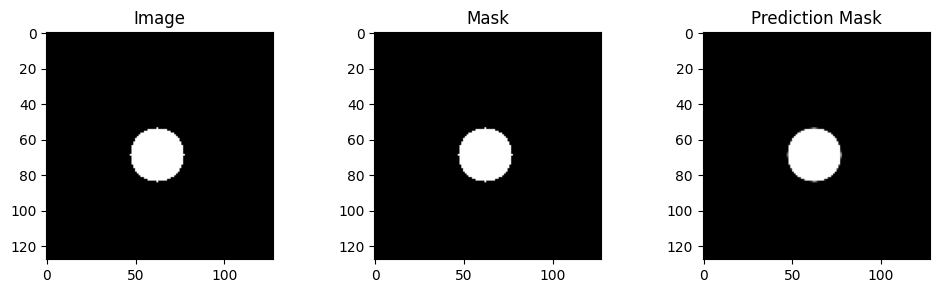

In [10]:
# -----------------------------------
# 6. Predictions:
# -----------------------------------

perds =model.predict(x_test[:3])

for i in range(3):

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plt.title('Image')
    plt.imshow(x_test[i])

    plt.subplot(1, 3, 2)
    plt.title('Mask')
    plt.imshow(y_test[i].squeeze(), cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title('Prediction Mask')
    plt.imshow(perds[i].squeeze(), cmap='gray')

    plt.tight_layout()
    plt.show()